<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/code/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [ ]:
!pip install bertopic
!pip install tweet-preprocessor
!pip install spacy-entity-linker
!pip install emoji

In [ ]:
from google.colab import drive

import pandas as pd
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

# Load Data

## Connect to Goole Drive


In [ ]:
# Connect to Goole Drive to use the data.
drive.mount('/content/drive')

## Load Labeled Datasets for Research on Information Operations.

In [ ]:
file_path = "/content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_3.gzip.parquet"

df = pd.read_parquet(file_path)

In [ ]:
df.head()

## Dataset Statistics

In [ ]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts().head())

# Clean Text

In [137]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [136]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [138]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

## Remove Engllish Stopwords

In [139]:
from nltk.corpus import stopwords
import nltk

In [140]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [141]:
df["clean_post_text"] = df["post_text"].apply(remove_stopwords)

In [142]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
100031,@72c233209dc9fa95258de4150952791cc619e258cc ch...,@72c233209dc9fa95258de4150952791cc619e258cc ch...
100032,White Stripes! https://e41b04e5a81c5f08e7ff672...,white stripes! https://e41b04e5a81c5f08e7ff672...
100148,To keep me just...,keep just...
100187,Lost and insecure you found me..,lost insecure found me..
100191,we're beautiful like diamonds in the sky,beautiful diamonds sky
100192,tonight you and I :),tonight :)
100193,eye to eye,eye eye
100194,diamonds :),diamonds :)
100196,so shine bright to night you and I,shine bright night
100197,Today stats: one new unfollower via https://ae...,today stats: new unfollower via https://ae0dbe...


# Topic Clustering

## **English** Topic Clustering

In [ ]:
# For Testing Only
df = df[df["post_language"] == "en"].head(200).copy()
print(f"english_df shape: {df.shape}")

In [ ]:
def english_topic_modeling(posts_text_lst, min_topic_size=10):

    embedding_model = SentenceTransformer("digio/Twitter4SSE")

    topic_model = BERTopic(
        embedding_model=embedding_model,
        language="english",
        min_topic_size=min_topic_size,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(posts_text_lst)

    return topics, probs, topic_model

In [ ]:
posts_text_lst = df["clean_post_text"].to_list()

topics, probs, topic_model = english_topic_modeling(posts_text_lst)

df["topic"] = topics

## Topics Stats

In [144]:
topic_count = topic_model.get_topic_info()
topic_count

,Topic,Count,Name,Representation,Representative_Docs
0,0,87,0_https_it_f82a72e78fbfe0c50f93a4f39249328c618...,"[https, it, f82a72e78fbfe0c50f93a4f39249328c61...",[@bb046ce8e8d47d6781f04b9c78930646819ee9b35d l...
1,1,86,1_that_me_shit_you,"[that, me, shit, you, cant, __, care, but, day...",[I Agree . Personality Over Looks . BUT You Ca...
2,2,14,2_cancer_03d691699fd4508b58fd930f2e8e8b17f6352...,"[cancer, 03d691699fd4508b58fd930f2e8e8b17f6352...",[“@03d691699fd4508b58fd930f2e8e8b17f6352591e2:...
3,3,13,3_meirc_training_dubai_uae,"[meirc, training, dubai, uae, https, managemen...",[Establishing Managing Project Management Offi...


In [157]:
topic_model.visualize_topics(custom_labels=True)

In [ ]:
topic_model.visualize_hierarchy()

## IO Drivers By Topic

In [153]:
topic_stats = (
    df.groupby("topic")
      .agg(
          Count=("topic", "count"),
          IO_Count=("is_control", lambda x: (~x).sum())   # count where is_control == False
      )
      .reset_index()
      .rename(columns={"topic": "Topic"})
)
topic_stats["Legitimate_posts"] = topic_stats["Count"] - topic_stats["IO_Count"]

topic_stats.head()



,Topic,Count,IO_Count,Legitimate_posts
0,0,87,1,86
1,1,86,0,86
2,2,14,0,14
3,3,13,0,13


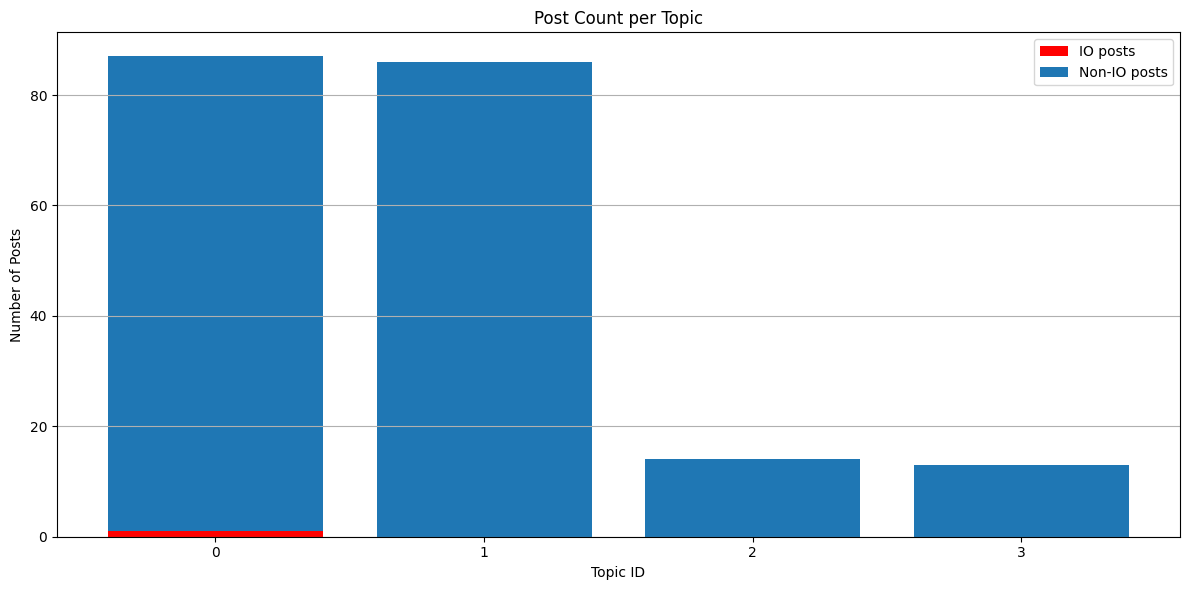

In [156]:
topics = topic_stats["Topic"]
io_count = topic_stats["IO_Count"]
legitimate_count = topic_stats["Legitimate_posts"]

plt.figure(figsize=(12, 6))

# 🔴 Bottom: IO posts
plt.bar(topics, io_count, label="IO posts", color="red")

# 🔵 Top: Non-IO posts stacked above IO
plt.bar(topics, legitimate_count, bottom=io, label="Non-IO posts")

plt.xlabel("Topic ID")
plt.ylabel("Number of Posts")
plt.title("Post Count per Topic")
plt.xticks(topics)
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()


# Named Entity Recognition (NER)

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

def extract_ner_entities(text):
      entities = ner_pipeline(text)
      return [ent["word"] for ent in entities]

In [ ]:
df["ner_entities"] = df["clean_post_text"].apply(extract_ner_entities)

In [126]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

,clean_post_text,ner_entities
100239,@6718298b85826dfa74019b2e1c40a2dda04dc19eb1 @f...,[McDonald's]
100240,@f82a72e78fbfe0c50f93a4f39249328c6186bf1c2c @6...,[Burger King]
100248,😫 @835b81473c2c443e78d3002fe144449608adb38df0:...,[Rihanna]
100249,That pic Rihanna horrible. She less ass,[Rihanna]
100280,➡➡ @71b35046faa71a6bf561522133460a5fd839307604...,[Margarita Day]
100283,😩RT @91b8a5775cf58fa6d6a8defe373d5644eb62f881d...,[instagram]
100300,Someone come scoop young thug !!!,[young thug]
100307,Who lives Wilmington wants bring food chill lol,[Wilmington]
100371,@4e502e5c2bdc6454e11dab941cd4aa65bda7df6ba0 Sa...,[Twitter@@]
100379,@0ca34bda92e507bb6a26d32b4966cbdbbe63d65ef0 co...,"[amber rose@@, aylor@@]"


# Save to parquet

In [158]:
from pathlib import Path
from google.colab import files


file_name = Path(file_path).name

# Create new filename
# output_path = str(Path(file_path).with_name(f"{base_name}_with_topic_and_ner.gzip.parquet"))

df.to_parquet(file_name, compression="gzip", index=False)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>